# Análisis Financiero — Acciones Argentinas

Análisis del comportamiento histórico de cuatro acciones argentinas (GGAL, YPF, TGS y PAM) durante el período 2020-2024.

El objetivo es comparar rendimiento, volatilidad y correlación entre activos de distintos sectores: bancario (GGAL), energético (YPF, PAM) y utilities de gas (TGS).

## Instalación e importación de librerías

In [19]:
!pip install yfinance
import yfinance as yf
import matplotlib.pyplot as plt

## 1. Descarga de datos

Obtenemos precios históricos desde Yahoo Finance usando yfinance para el período 2020-2024.

In [20]:
# Descargamos datos históricos de GGAL (Grupo Financiero Galicia)
ggal = yf.download("GGAL", start="2020-01-01", end="2024-12-31")
print(ggal.head())

[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open   Volume
Ticker           GGAL       GGAL       GGAL       GGAL     GGAL
Date                                                           
2020-01-02  12.406452  12.671063  12.194763  12.361091  2010900
2020-01-03  11.945275  12.300610  11.627743  12.111602  1401500
2020-01-06  12.073798  12.293047  11.642861  11.726024   958400
2020-01-07  11.998194  12.111599  11.846988  12.013315   744100
2020-01-08  12.126721  12.406452  11.892351  11.892351  1310400


In [21]:
# Exploramos la estructura del dataset
print(ggal.shape)
print(ggal.dtypes)

(1257, 5)
Price   Ticker
Close   GGAL      float64
High    GGAL      float64
Low     GGAL      float64
Open    GGAL      float64
Volume  GGAL        int64
dtype: object


In [22]:
# Descargamos los 4 tickers juntos
tickers = ["GGAL", "YPF", "TGS", "PAM"]
datos = yf.download(tickers, start="2020-01-01", end="2024-12-31")["Close"]
print(datos.head())

[*********************100%***********************]  4 of 4 completed

Ticker           GGAL    PAM   TGS    YPF
Date                                     
2020-01-02  12.406452  15.84  7.02  11.26
2020-01-03  11.945275  15.50  6.97  11.16
2020-01-06  12.073798  15.35  6.96  11.14
2020-01-07  11.998194  15.26  7.02  10.91
2020-01-08  12.126721  14.95  6.90  10.98


## 2. Evolución histórica de precios

Visualizamos cómo evolucionó el precio de cada acción en el período.

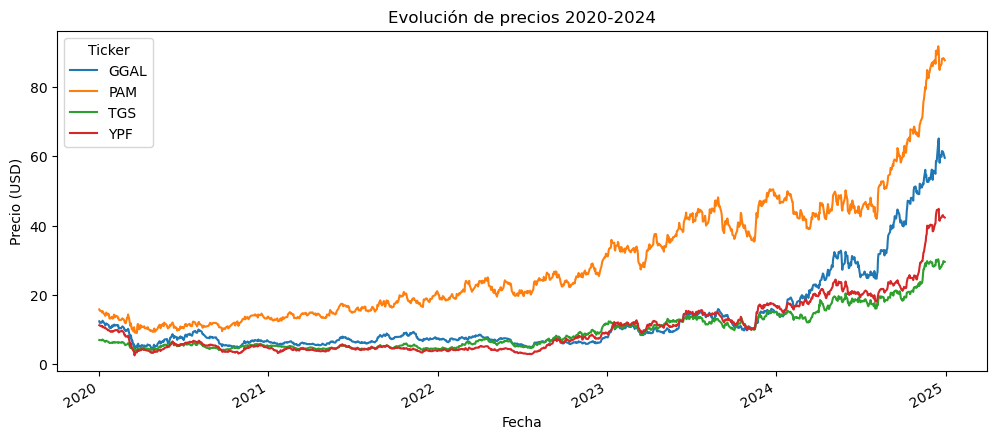

In [23]:
datos.plot(figsize=(12,5), title='Evolución de precios 2020-2024')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.show()

## 3. Rendimiento comparado base 100

Normalizamos los precios para comparar el rendimiento relativo entre acciones,
independientemente de su precio absoluto. Todas arrancan desde 100 en enero 2020.

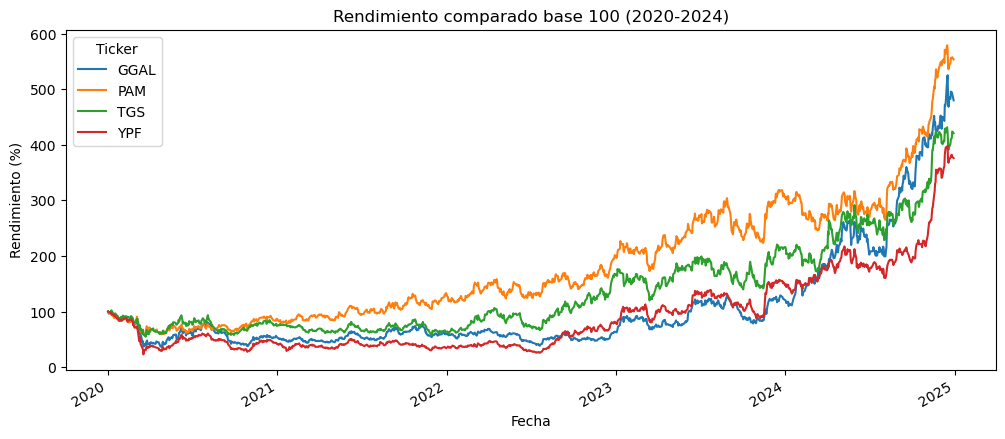

In [24]:
normalizado = (datos / datos.iloc[0]) * 100
normalizado.plot(figsize=(12,5), title='Rendimiento comparado base 100 (2020-2024)')
plt.xlabel('Fecha')
plt.ylabel('Rendimiento (%)')
plt.show()

## 4. Rendimiento acumulado total

Calculamos el retorno total de cada acción durante todo el período 2020-2024.

In [25]:
rendimiento = ((datos.iloc[-1] - datos.iloc[0]) / datos.iloc[0]) * 100
print(rendimiento.round(2))

Ticker
GGAL    380.42
PAM     454.04
TGS     321.23
YPF     276.29
dtype: float64


## 5. Volatilidad anualizada

Medimos el riesgo de cada acción a través del desvío estándar de los retornos diarios,
anualizado por convención financiera (multiplicado por √252, los días hábiles del año).

Ticker
GGAL    59.83
PAM     48.79
TGS     54.69
YPF     62.71
dtype: float64


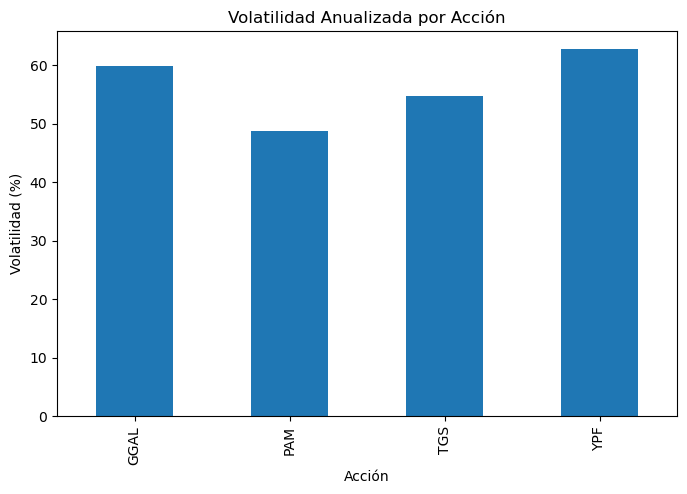

In [26]:
volatilidad = datos.pct_change().std() * (252 ** 0.5) * 100
print(volatilidad.round(2))

volatilidad.plot(kind='bar', figsize=(8,5), title='Volatilidad Anualizada por Acción')
plt.xlabel('Acción')
plt.ylabel('Volatilidad (%)')
plt.show()

## 6. Correlación entre activos

Analizamos si las acciones se mueven juntas o de forma independiente.
Valores cercanos a 1 indican alta correlación; cercanos a 0 indican independencia.

Ticker  GGAL   PAM   TGS   YPF
Ticker                        
GGAL    1.00  0.71  0.67  0.72
PAM     0.71  1.00  0.75  0.65
TGS     0.67  0.75  1.00  0.64
YPF     0.72  0.65  0.64  1.00


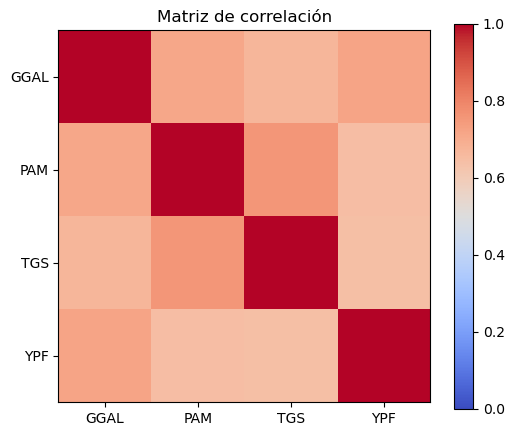

In [27]:
correlacion = datos.pct_change().corr()
print(correlacion.round(2))

fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(correlacion, cmap='coolwarm', vmin=0, vmax=1)
plt.colorbar(im)
ax.set_xticks(range(len(correlacion.columns)))
ax.set_yticks(range(len(correlacion.columns)))
ax.set_xticklabels(correlacion.columns)
ax.set_yticklabels(correlacion.columns)
plt.title('Matriz de correlación')
plt.show()

## 7. Retorno anual por año

Comparamos el rendimiento de cada acción año a año para identificar
en qué períodos cada sector brilló o sufrió.

Ticker        GGAL    PAM     TGS     YPF
Date                                     
2020-12-31     NaN    NaN     NaN     NaN
2021-12-31    9.46  53.19  -14.62  -18.72
2022-12-31    8.06  51.30  165.77  140.58
2023-12-31   92.32  55.04   27.88   87.05
2024-12-31  292.04  77.22   95.96  146.48


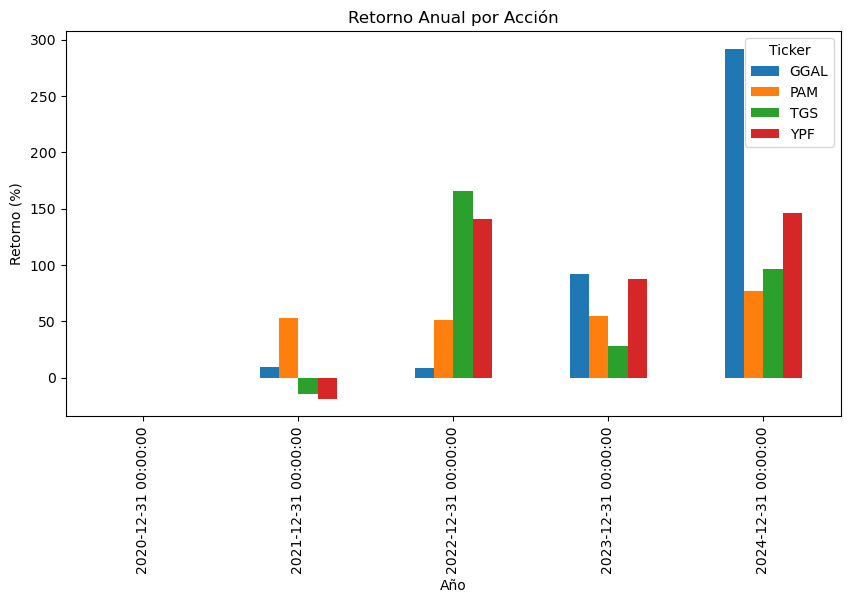

In [28]:
retorno_anual = datos.resample('YE').last().pct_change() * 100
print(retorno_anual.round(2))

retorno_anual.plot(kind='bar', figsize=(10,5), title='Retorno Anual por Acción')
plt.xlabel('Año')
plt.ylabel('Retorno (%)')
plt.show()

## 8. Ratio de Sharpe

Medimos el retorno ajustado por riesgo de cada acción.
Fórmula: (Retorno anualizado - Tasa libre de riesgo) / Volatilidad anualizada.
Usamos una tasa libre de riesgo del 4% anual (referencia bonos del Tesoro de EEUU).

Ticker
GGAL    0.76
PAM     0.86
TGS     0.72
YPF     0.67
dtype: float64


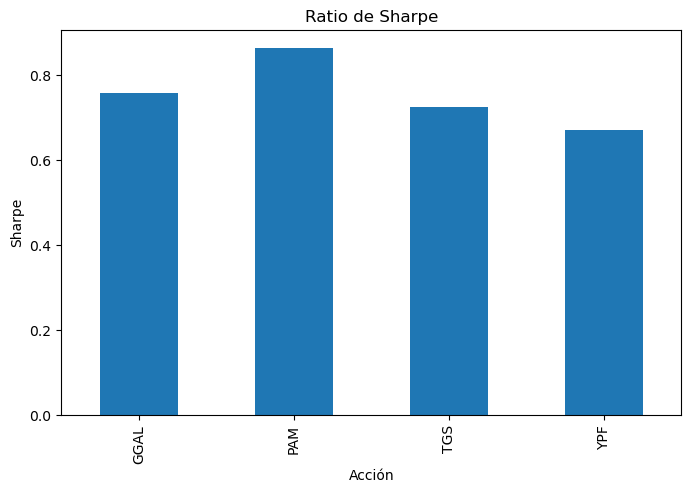

In [29]:
tasa_libre_riesgo = 0.04
retorno_anualizado = datos.pct_change().mean() * 252
sharpe = (retorno_anualizado - tasa_libre_riesgo) / (datos.pct_change().std() * (252 ** 0.5))
print(sharpe.round(2))

sharpe.plot(kind='bar', figsize=(8,5), title='Ratio de Sharpe')
plt.xlabel('Acción')
plt.ylabel('Sharpe')
plt.show()